# Scania APS failure: EDA and predictive maintenance model

## tl;dr

- **Rare-event problem:** 1,000 of 60,000 training cases (1.67%) are APS-related failures.
- **Holdout performance:** the validation-selected threshold of **0.143** detects **94.9%** of APS failures at **49.2%** precision; PR-AUC is **0.882**.
- **Operational value:** asymmetric holdout cost falls from **187,500** for an always-negative policy to **13,170** cost units (**93.0% lower**), under the stated 500:10 false-negative/false-positive cost ratio.
- **Data quality:** 8.3% of training feature cells are missing and 8 features are more than half missing. Missingness must remain inside the monitored production feature contract.
- **Interpretation limit:** sensor names are anonymized, so feature importance reveals predictive signals, not mechanical root causes.

## Context & Methods

The goal is to detect trucks whose failures relate to the air pressure system (APS). The dataset contains anonymized operational sensor readings, so findings identify predictive signals rather than mechanical root causes.

### Key Assumptions

- Each row is one truck/operational case; no stable entity or timestamp is provided.
- The supplied training and test files are treated as fixed development and holdout populations.
- `na` is a missing-value sentinel, not a literal category or zero.
- Model selection uses a stratified validation split from the training file only.
- The operational score follows the dataset convention: false negative = 500 cost units and false positive = 10. This is a decision proxy, not a currency amount.

In [1]:
from pathlib import Path
import json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from scipy.stats import ks_2samp
from sklearn.base import clone
from sklearn.compose import TransformedTargetRegressor
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    average_precision_score, confusion_matrix, f1_score, precision_score,
    recall_score, roc_auc_score, precision_recall_curve
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
RANDOM_STATE = 42
FN_COST, FP_COST = 500, 10
ROOT = Path.cwd()
OUTPUT = ROOT / "outputs"
CHARTS = OUTPUT / "charts"
OUTPUT.mkdir(exist_ok=True)
CHARTS.mkdir(exist_ok=True)
TRAIN_PATH = Path("C:/Users/Minahil Ahsan Awan/Downloads/aps_failure_training_set.csv")
TEST_PATH = Path("C:/Users/Minahil Ahsan Awan/Downloads/aps_failure_test_set.csv")

## Data

### 1. Load and validate inputs

The first 20 lines are license text. Values are parsed as numeric after mapping `na` to missing.

In [2]:
train = pd.read_csv(TRAIN_PATH, skiprows=20, na_values="na")
test = pd.read_csv(TEST_PATH, skiprows=20, na_values="na")
assert train.columns.equals(test.columns)
assert set(train["class"].unique()) == {"neg", "pos"}
assert set(test["class"].unique()) == {"neg", "pos"}
feature_cols = [c for c in train.columns if c != "class"]
y = train["class"].eq("pos").astype(int)
y_test = test["class"].eq("pos").astype(int)
X = train[feature_cols]
X_test = test[feature_cols]

profile = pd.DataFrame({
    "split": ["training", "test"],
    "rows": [len(train), len(test)],
    "features": [len(feature_cols), len(feature_cols)],
    "positive_rows": [int(y.sum()), int(y_test.sum())],
    "positive_rate": [float(y.mean()), float(y_test.mean())],
    "missing_cells": [int(X.isna().sum().sum()), int(X_test.isna().sum().sum())],
    "missing_rate": [float(X.isna().mean().mean()), float(X_test.isna().mean().mean())],
    "exact_duplicate_rows": [int(train.duplicated().sum()), int(test.duplicated().sum())],
})
profile

,split,rows,features,positive_rows,positive_rate,missing_cells,missing_rate,exact_duplicate_rows
0,training,60000,170,1000,0.016667,850015,0.083335,0
1,test,16000,170,375,0.023438,228680,0.084074,0


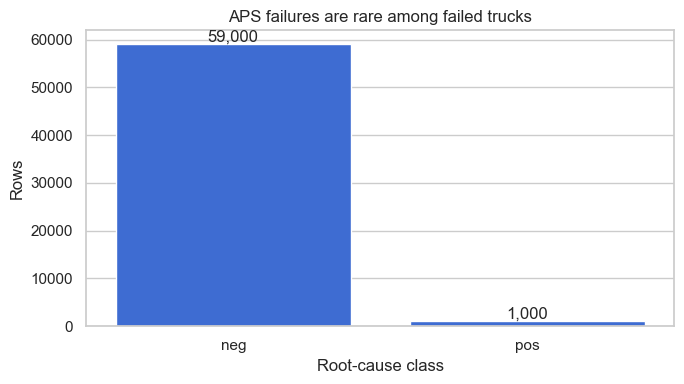

In [3]:
class_counts = train["class"].value_counts().reindex(["neg", "pos"])
fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(x=class_counts.index, y=class_counts.values, color="#2563eb", ax=ax)
ax.set(title="APS failures are rare among failed trucks", xlabel="Root-cause class", ylabel="Rows")
for i, v in enumerate(class_counts.values): ax.text(i, v, f"{v:,}", ha="center", va="bottom")
fig.tight_layout(); fig.savefig(CHARTS / "class_imbalance.png", dpi=160); plt.show()

### 2. Diagnose missingness and distribution stability

Missingness is both a data-quality concern and a possible operational signal. Train/test distribution drift is screened using absolute missing-rate change and the Kolmogorov–Smirnov statistic.

In [4]:
missing = pd.DataFrame({
    "train_missing_rate": X.isna().mean(),
    "test_missing_rate": X_test.isna().mean(),
    "pos_missing_rate": X[y.eq(1)].isna().mean(),
    "neg_missing_rate": X[y.eq(0)].isna().mean(),
})
missing["target_missing_gap"] = missing["pos_missing_rate"] - missing["neg_missing_rate"]
missing["split_missing_gap"] = missing["test_missing_rate"] - missing["train_missing_rate"]
missing = missing.sort_values("train_missing_rate", ascending=False)
missing.head(15)

,train_missing_rate,test_missing_rate,pos_missing_rate,neg_missing_rate,target_missing_gap,split_missing_gap
br_000,0.821067,0.820562,0.090,0.833458,-0.743458,-0.000504
bq_000,0.812033,0.811312,0.087,0.824322,-0.737322,-0.000721
bp_000,0.795667,0.795063,0.083,0.807746,-0.724746,-0.000604
bo_000,0.772217,0.773500,0.078,0.783983,-0.705983,0.001283
ab_000,0.772150,0.772687,0.771,0.772169,-0.001169,0.000537
cr_000,0.772150,0.772687,0.771,0.772169,-0.001169,0.000537
bn_000,0.733483,0.732062,0.074,0.744661,-0.670661,-0.001421
bm_000,0.659150,0.659125,0.071,0.669119,-0.598119,-0.000025
bl_000,0.454617,0.451625,0.067,0.461186,-0.394186,-0.002992
bk_000,0.383900,0.380875,0.064,0.389322,-0.325322,-0.003025


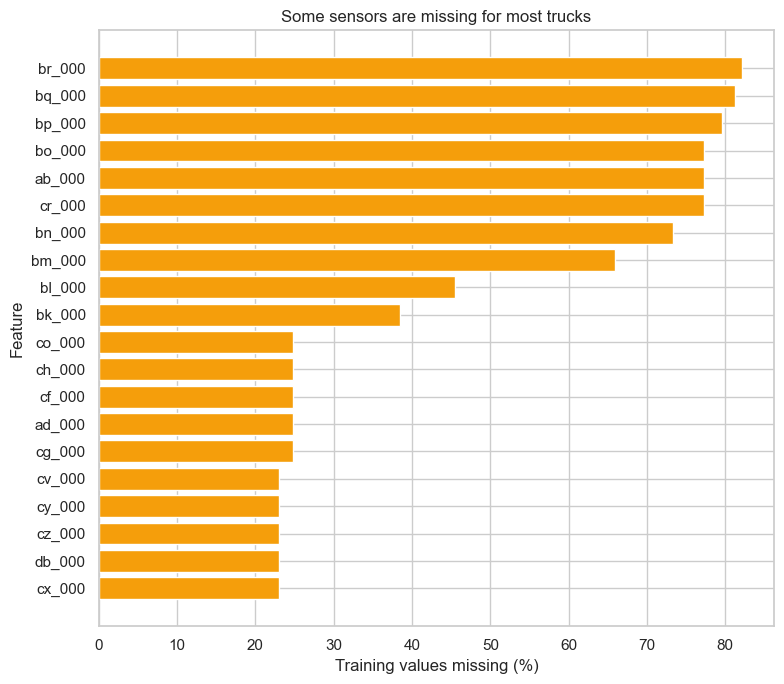

In [5]:
plot_missing = missing.head(20).sort_values("train_missing_rate")
fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(plot_missing.index, plot_missing["train_missing_rate"] * 100, color="#f59e0b")
ax.set(title="Some sensors are missing for most trucks", xlabel="Training values missing (%)", ylabel="Feature")
fig.tight_layout(); fig.savefig(CHARTS / "missingness.png", dpi=160); plt.show()

In [6]:
rng = np.random.default_rng(RANDOM_STATE)
train_idx = rng.choice(len(X), size=min(12000, len(X)), replace=False)
test_idx = rng.choice(len(X_test), size=min(12000, len(X_test)), replace=False)
drift_rows = []
for col in feature_cols:
    a = X.iloc[train_idx][col].dropna().to_numpy()
    b = X_test.iloc[test_idx][col].dropna().to_numpy()
    ks = ks_2samp(a, b).statistic if len(a) and len(b) else np.nan
    drift_rows.append((col, ks, missing.loc[col, "split_missing_gap"]))
drift = pd.DataFrame(drift_rows, columns=["feature", "ks_stat", "missing_rate_delta"])
drift["drift_score"] = drift[["ks_stat", "missing_rate_delta"]].abs().max(axis=1)
drift = drift.sort_values("drift_score", ascending=False)
drift.head(12)

,feature,ks_stat,missing_rate_delta,drift_score
77,bq_000,0.026580,-0.000721,0.026580
74,bn_000,0.024221,-0.001421,0.024221
78,br_000,0.023412,-0.000504,0.023412
76,bp_000,0.022297,-0.000604,0.022297
133,de_000,0.019841,0.002350,0.019841
128,cz_000,0.016471,0.002242,0.016471
48,az_006,0.016393,0.000817,0.016393
123,ct_000,0.016197,0.002242,0.016197
63,bc_000,0.016150,0.002333,0.016150
40,ay_008,0.015906,0.000817,0.015906


## Results

### 3. Train a cost-sensitive failure classifier

An Extra Trees ensemble is used because it captures nonlinear sensor interactions and produces feature importances. Median imputation is fitted inside the pipeline to prevent leakage. Class weighting helps expose the rare failure class. The decision threshold is selected only on the validation fold to minimize asymmetric cost.

In [7]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)
model = Pipeline([
    ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
    ("classifier", ExtraTreesClassifier(
        n_estimators=320, min_samples_leaf=2, max_features="sqrt",
        class_weight="balanced", n_jobs=-1, random_state=RANDOM_STATE
    )),
])
model.fit(X_train, y_train)
valid_prob = model.predict_proba(X_valid)[:, 1]

thresholds = np.unique(np.r_[np.linspace(0.001, 0.999, 999), valid_prob])
threshold_rows = []
for threshold in thresholds:
    pred = valid_prob >= threshold
    tn, fp, fn, tp = confusion_matrix(y_valid, pred, labels=[0, 1]).ravel()
    threshold_rows.append((threshold, tn, fp, fn, tp, fn * FN_COST + fp * FP_COST))
threshold_table = pd.DataFrame(threshold_rows, columns=["threshold", "tn", "fp", "fn", "tp", "cost"])
best_row = threshold_table.loc[threshold_table["cost"].idxmin()]
best_threshold = float(best_row["threshold"])
best_row.to_frame("validation_result")

,validation_result
threshold,0.142853
tn,11468.000000
fp,332.000000
fn,6.000000
tp,194.000000
cost,6320.000000


In [8]:
def evaluate(name, y_true, probability, threshold):
    pred = probability >= threshold
    tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=[0, 1]).ravel()
    return {
        "model": name, "threshold": float(threshold), "tn": int(tn), "fp": int(fp),
        "fn": int(fn), "tp": int(tp), "precision": precision_score(y_true, pred, zero_division=0),
        "recall": recall_score(y_true, pred, zero_division=0), "f1": f1_score(y_true, pred, zero_division=0),
        "pr_auc": average_precision_score(y_true, probability), "roc_auc": roc_auc_score(y_true, probability),
        "cost": int(fn * FN_COST + fp * FP_COST),
    }

valid_metrics = evaluate("Extra Trees (validation)", y_valid, valid_prob, best_threshold)
default_metrics = evaluate("Extra Trees (0.50 threshold)", y_valid, valid_prob, 0.50)
pd.DataFrame([valid_metrics, default_metrics]).set_index("model").round(4)

,threshold,tn,fp,fn,tp,precision,recall,f1,pr_auc,roc_auc,cost
model,,,,,,,,,,,
Extra Trees (validation),0.1429,11468,332,6,194,0.3688,0.970,0.5344,0.8533,0.9946,6320
Extra Trees (0.50 threshold),0.5000,11756,44,43,157,0.7811,0.785,0.7830,0.8533,0.9946,21940


### 4. Refit on all training data and evaluate once on the holdout test set

The test labels are not used for feature selection, fitting, or threshold choice. They are opened only for this final evaluation.

In [9]:
final_model = clone(model).fit(X, y)
test_prob = final_model.predict_proba(X_test)[:, 1]
test_metrics = evaluate("Extra Trees (test)", y_test, test_prob, best_threshold)

dummy = DummyClassifier(strategy="most_frequent").fit(np.zeros((len(y), 1)), y)
dummy_prob = dummy.predict_proba(np.zeros((len(y_test), 1)))[:, 1]
dummy_metrics = evaluate("Always negative baseline", y_test, dummy_prob, 0.50)
metrics = pd.DataFrame([dummy_metrics, test_metrics])
metrics.set_index("model").round(4)

,threshold,tn,fp,fn,tp,precision,recall,f1,pr_auc,roc_auc,cost
model,,,,,,,,,,,
Always negative baseline,0.5000,15625,0,375,0,0.0000,0.0000,0.0000,0.0234,0.5000,187500
Extra Trees (test),0.1429,15258,367,19,356,0.4924,0.9493,0.6485,0.8824,0.9942,13170


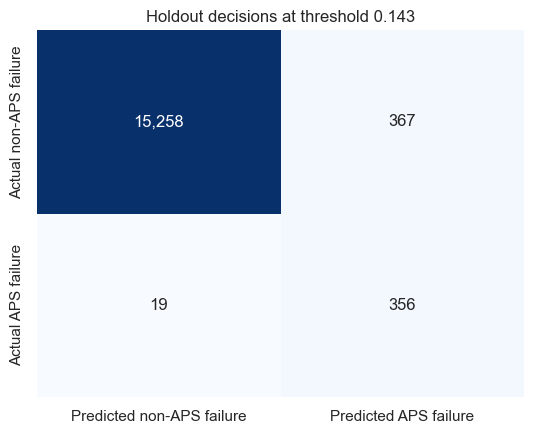

In [10]:
cm = np.array([[test_metrics["tn"], test_metrics["fp"]], [test_metrics["fn"], test_metrics["tp"]]])
fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(cm, annot=True, fmt=",", cmap="Blues", cbar=False, ax=ax,
            xticklabels=["Predicted non-APS failure", "Predicted APS failure"],
            yticklabels=["Actual non-APS failure", "Actual APS failure"])
ax.set_title(f"Holdout decisions at threshold {best_threshold:.3f}")
fig.tight_layout(); fig.savefig(CHARTS / "test_confusion_matrix.png", dpi=160); plt.show()

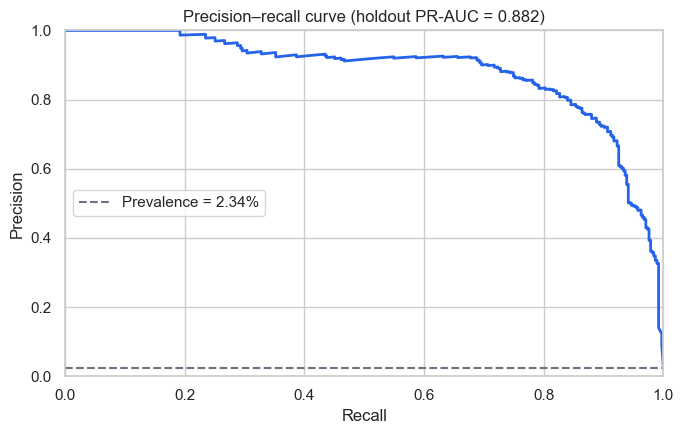

In [11]:
precision, recall, _ = precision_recall_curve(y_test, test_prob)
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(recall, precision, color="#2563eb", lw=2)
ax.axhline(y_test.mean(), color="#6b7280", ls="--", label=f"Prevalence = {y_test.mean():.2%}")
ax.set(title=f"Precision–recall curve (holdout PR-AUC = {test_metrics['pr_auc']:.3f})",
       xlabel="Recall", ylabel="Precision", xlim=(0, 1), ylim=(0, 1))
ax.legend(); fig.tight_layout(); fig.savefig(CHARTS / "precision_recall_curve.png", dpi=160); plt.show()

### 5. Identify the strongest predictive signals

Feature importance measures predictive contribution inside the ensemble, not causal or mechanical importance. Missingness indicators are retained when the model finds them useful.

In [12]:
names = final_model.named_steps["imputer"].get_feature_names_out(feature_cols)
importances = final_model.named_steps["classifier"].feature_importances_
feature_importance = (pd.DataFrame({"feature": names, "importance": importances})
                      .sort_values("importance", ascending=False).reset_index(drop=True))
top_features = feature_importance.head(20)
top_features

,feature,importance
0,missingindicator_br_000,0.053232
1,missingindicator_bp_000,0.048635
2,missingindicator_bq_000,0.038858
3,missingindicator_bn_000,0.038669
4,missingindicator_bo_000,0.037969
5,cq_000,0.024243
6,missingindicator_bm_000,0.023197
7,bt_000,0.021431
8,an_000,0.020217
9,bg_000,0.019473


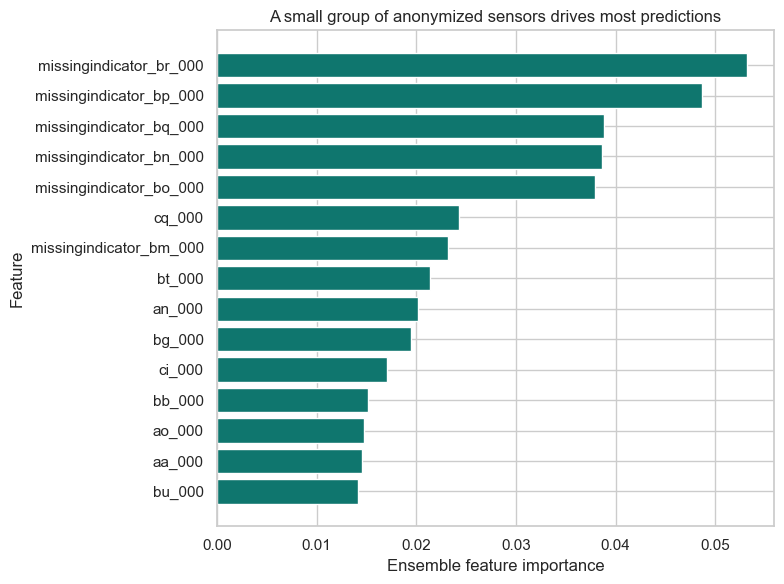

In [13]:
plot_imp = top_features.head(15).sort_values("importance")
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(plot_imp["feature"], plot_imp["importance"], color="#0f766e")
ax.set(title="A small group of anonymized sensors drives most predictions", xlabel="Ensemble feature importance", ylabel="Feature")
fig.tight_layout(); fig.savefig(CHARTS / "feature_importance.png", dpi=160); plt.show()

In [14]:
base_top = [f for f in top_features["feature"] if not f.startswith("missingindicator_")][:10]
signal_rows = []
for col in base_top:
    neg_med = X.loc[y.eq(0), col].median()
    pos_med = X.loc[y.eq(1), col].median()
    signal_rows.append({
        "feature": col, "negative_median": neg_med, "positive_median": pos_med,
        "median_log10_ratio": np.log10((abs(pos_med) + 1) / (abs(neg_med) + 1)),
        "positive_missing_rate": X.loc[y.eq(1), col].isna().mean(),
        "negative_missing_rate": X.loc[y.eq(0), col].isna().mean(),
    })
signal_comparison = pd.DataFrame(signal_rows)
signal_comparison.round(4)

,feature,negative_median,positive_median,median_log10_ratio,positive_missing_rate,negative_missing_rate
0,cq_000,2317872.000,47163072.00,1.3085,0.042,0.0110
1,bt_000,30471.945,585163.41,1.2834,0.011,0.0026
2,an_000,1883210.000,33124476.00,1.2453,0.043,0.0102
3,bg_000,984816.000,17711194.00,1.2549,0.043,0.0102
4,ci_000,1824220.800,36076429.92,1.2961,0.010,0.0056
5,bb_000,2319400.000,47370562.00,1.3101,0.041,0.0102
6,ao_000,1609098.000,28430622.00,1.2472,0.040,0.0093
7,aa_000,30416.000,584994.00,1.2840,0.000,0.0000
8,bu_000,2317872.000,47163072.00,1.3085,0.042,0.0110
9,bv_000,2317872.000,47163072.00,1.3085,0.042,0.0110


## Takeaways

### 6. Save a deployable decision package and audit evidence

The package stores preprocessing, the fitted classifier, the validation-selected threshold, expected feature order, and the cost assumptions. A production system should monitor input drift and missingness, and recalibrate the threshold using real maintenance economics.

In [15]:
package = {
    "pipeline": final_model,
    "threshold": best_threshold,
    "feature_columns": feature_cols,
    "positive_label": "pos",
    "cost_assumptions": {"false_negative": FN_COST, "false_positive": FP_COST},
    "training_source": TRAIN_PATH.name,
}
joblib.dump(package, OUTPUT / "aps_failure_model.joblib")
profile.to_csv(OUTPUT / "data_profile.csv", index=False)
missing.reset_index(names="feature").to_csv(OUTPUT / "missingness_profile.csv", index=False)
drift.to_csv(OUTPUT / "distribution_drift.csv", index=False)
feature_importance.to_csv(OUTPUT / "feature_importance.csv", index=False)
signal_comparison.to_csv(OUTPUT / "top_signal_comparison.csv", index=False)
metrics.to_csv(OUTPUT / "model_metrics.csv", index=False)

summary = {
    "training_rows": len(train), "test_rows": len(test), "feature_count": len(feature_cols),
    "train_positive_count": int(y.sum()), "train_positive_rate": float(y.mean()),
    "test_positive_count": int(y_test.sum()), "test_positive_rate": float(y_test.mean()),
    "train_missing_rate": float(X.isna().mean().mean()),
    "features_over_50pct_missing": int((X.isna().mean() > 0.5).sum()),
    "duplicate_training_rows": int(train.duplicated().sum()),
    "best_threshold": best_threshold, "validation_metrics": valid_metrics,
    "test_metrics": test_metrics, "baseline_metrics": dummy_metrics,
    "top_features": top_features.head(10).to_dict("records"),
    "largest_target_missing_gaps": (missing.reindex(missing.target_missing_gap.abs().sort_values(ascending=False).index)
                                     .head(10).reset_index(names="feature").to_dict("records")),
    "largest_drift": drift.head(10).to_dict("records"),
}
(OUTPUT / "summary.json").write_text(json.dumps(summary, indent=2), encoding="utf-8")
summary

{'training_rows': 60000,
 'test_rows': 16000,
 'feature_count': 170,
 'train_positive_count': 1000,
 'train_positive_rate': 0.016666666666666666,
 'test_positive_count': 375,
 'test_positive_rate': 0.0234375,
 'train_missing_rate': 0.08333480392156863,
 'features_over_50pct_missing': 8,
 'duplicate_training_rows': 0,
 'best_threshold': 0.1428528162210973,
 'validation_metrics': {'model': 'Extra Trees (validation)',
  'threshold': 0.1428528162210973,
  'tn': 11468,
  'fp': 332,
  'fn': 6,
  'tp': 194,
  'precision': 0.3688212927756654,
  'recall': 0.97,
  'f1': 0.5344352617079889,
  'pr_auc': 0.853333422195281,
  'roc_auc': 0.9946358050847457,
  'cost': 6320},
 'test_metrics': {'model': 'Extra Trees (test)',
  'threshold': 0.1428528162210973,
  'tn': 15258,
  'fp': 367,
  'fn': 19,
  'tp': 356,
  'precision': 0.49239280774550487,
  'recall': 0.9493333333333334,
  'f1': 0.6484517304189436,
  'pr_auc': 0.882407810918961,
  'roc_auc': 0.9941515093333333,
  'cost': 13170},
 'baseline_metric